# 1D Overdamped Oscillator with Physics-Informed Neural Networks

This notebook demonstrates how to solve the **damped harmonic oscillator** equation using Physics-Informed Neural Networks (PINNs). The damped harmonic oscillator is governed by the second-order differential equation:

$$\frac{d^2x}{dt^2} + \beta \frac{dx}{dt} + \omega x = 0$$

where:
- $\omega$ is the angular frequency squared
- $\beta$ is the damping coefficient
- $x(t)$ is the displacement

Three approaches are demonstrated:
1. **Standard PINN** — single network trained on the full domain
2. **FB-PINN** — domain decomposition with overlapping sub-networks (`PartitionFB`)
3. **AL-PINN** — Augmented Lagrangian enforcement of initial conditions


In [1]:
import pinns
from pinns import (
    DomainCubic,
    ProblemStrong,
    PartitionFB,
    create_model,
    Trainer,
    derivative,
)
import numpy as np
import matplotlib.pyplot as plt


# Define the Problem

In this section, we set up all the components needed to define our PINN problem:
1. Physical parameters of the oscillator
2. The differential equation (residual form)
3. The computational domain
4. Initial and boundary conditions

## Parameters of the Model

We define the physical parameters for our oscillator system:
- **beta ($\beta$)**: Damping coefficient (0.1) - controls how quickly oscillations decay
- **omega ($\omega$)**: Angular frequency squared (10) - determines the natural frequency
- **x0**: Initial positions for the oscillator
- **t_max**: Time of simulation

With $\beta = 0.1$ and $\omega = 10$, we have $\omega > \beta^2/4$, which corresponds to the **underdamped** regime where the system oscillates while decaying.

The parameters **x0** and **t_max** is not actually a parameter but the initial condition and the simulation time. We just set them in here as it will send them to the analytic solution to compare.

In [2]:
beta = .1
omega = 10
x0 = 1
t_max = 10

## Domain

`DomainCubic` defines a hyper-rectangular domain. For a pure time-evolution problem, pass only `time=(t_min, t_max)`.

- **`space`** — list of `[min, max]` pairs for each spatial dimension (omit for time-only problems)
- **`time`** — `(t_min, t_max)` tuple for the time axis

Subdomain decomposition is configured later via `domain.set_partition(time=N)` and passed to `create_model` as `partition=PartitionFB(...)`.


In [3]:
domain = DomainCubic(time=(0, t_max))
print(domain)


DomainCubic(space=[], time=[0.0, 10.0], n_conditions=0)


## Differential Equation

### The ODE Residual

The `model_overdamped` function computes the residual of the damped oscillator equation. PINNs minimise this residual over the domain:

$$\mathcal{R} = \frac{d^2x}{dt^2} + \beta \frac{dx}{dt} + \omega x = 0$$

Residual functions receive three arguments:

- **X** — collocation points, shape $(N, n_{inputs})$
- **U** — network output at those points, shape $(N, n_{outputs})$
- **params** — dictionary with keys `"fixed"` (known constants) and `"dynamic"` (inferred parameters in inverse problems)

Derivatives are computed with `pinns.derivative(output, X, output_col, derivative_orders)`, e.g.:

```python
x_t  = derivative(x, X, 0, (0,))      # dx/dt
x_tt = derivative(x, X, 0, (0, 0))    # d²x/dt²
```

The function must return a single JAX array of residuals (shape $(N, 1)$).


In [4]:
problem = ProblemStrong(
    domain=domain,
    output_names=["x"],
)

# Column convention:  X[:, 0] = t,  U[:, 0] = x

def model_overdamped(X, U, params, derivative):
    omega = params["fixed"]["omega"]
    beta  = params["fixed"]["beta"]

    x    = U[:, 0:1]
    x_t  = derivative(x, X, 0, (0,))      # dx/dt
    x_tt = derivative(x, X, 0, (0, 0))    # d²x/dt²

    return x_tt + beta * x_t + omega * x

problem.add_inner(model_overdamped, name="ode")

# Initial condition: x(0) = x0
problem.add_initial(1, outputs="x", name="Ix")

# Initial condition: x'(0) = 0
def initial_velocity(X, U, params, derivative):
    x   = U[:, 0:1]
    x_t = derivative(x, X, 0, (0,))
    return x_t

problem.add_initial(initial_velocity, outputs="x", name="Ivx")

# Fixed physical parameters
problem.add_fixed("omega", omega)
problem.add_fixed("beta",  beta)
problem.add_fixed("x0",    x0)

print(problem)


ProblemStrong(domain=DomainCubic, n_dims=1, n_outputs=1, inner=1, boundary=0, initial=2, fixed=['omega', 'beta', 'x0'], inferred=[])


### Analytical Solution (Optional)

In this case we know the analitic solution of the problem, we will add it to evaluate the model error. For the underdamped case ($\omega > \beta^2/4$), the analytical solution is:

$$x(t) = x_0 e^{-\frac{\beta t}{2}} \cos\left(\sqrt{\omega - \frac{\beta^2}{4}} \cdot t\right)$$

The function will take the input and params and return a list of solutions for each equation in the same order than in the residuals definition.

In [5]:
def model_underdamped_analytic(X, params):
    omega = params["fixed"]["omega"]
    beta  = params["fixed"]["beta"]
    x0    = params["fixed"]["x0"]
    t     = X[:, 0:1]
    return x0 * np.exp(-beta * t / 2) * np.cos(np.sqrt(omega - (beta**2) / 4) * t)

problem.add_solution(model_underdamped_analytic)
problem.show_problem()


<IPython.core.display.Math object>

'\\min_\\theta\\;\\mathcal{L}(\\theta)=\\frac{w_{ode}}{N_{ode}}\\left\\|\\mathcal{R}_{ode}\\right\\|_2^2 + \\frac{w_{Ix}}{N_{Ix}}\\left\\|\\mathcal{R}_{Ix}\\right\\|_2^2 + \\frac{w_{Ivx}}{N_{Ivx}}\\left\\|\\mathcal{R}_{Ivx}\\right\\|_2^2 \\\\[4pt]\\begin{array}{l} \\mathcal{R}_{ode}:\\text{ PDE residual — ode (region: all)} \\\\ N_{ode}:\\text{ \\# samples for ode} \\\\ w_{ode}:\\text{ weight for ode} \\\\ \\mathcal{R}_{Ix}:\\text{ IC residual — Ix (region: initial)} \\\\ N_{Ix}:\\text{ \\# samples for Ix} \\\\ w_{Ix}:\\text{ weight for Ix} \\\\ \\mathcal{R}_{Ivx}:\\text{ IC residual — Ivx (region: initial)} \\\\ N_{Ivx}:\\text{ \\# samples for Ivx} \\\\ w_{Ivx}:\\text{ weight for Ivx} \\end{array}'

# Solve with Standard PINN

## Model

We build the model with `create_model`: a normalised FNN with `tanh` activations, outputting in the physical range $[-x_0, x_0]$.


In [6]:
network = create_model(
    domain,
    output_dim=1,
    hidden_dims=(128, 128, 128),
    activation="tanh",
    denormalize=True,
    output_range=(-x0, x0),
)
print(network)


ModelBase(output_dim=1)
  [Normalize_0] Normalize(n_coord=1, n_context=0, context_scaled=False)
  [FNN_1] FNN(layer_sizes=[1, 128, 128, 128, 1])
  [Denormalize_2] Denormalize(scaled=True)


## Training


Starting training for 10000 epochs (JIT-compiled)...


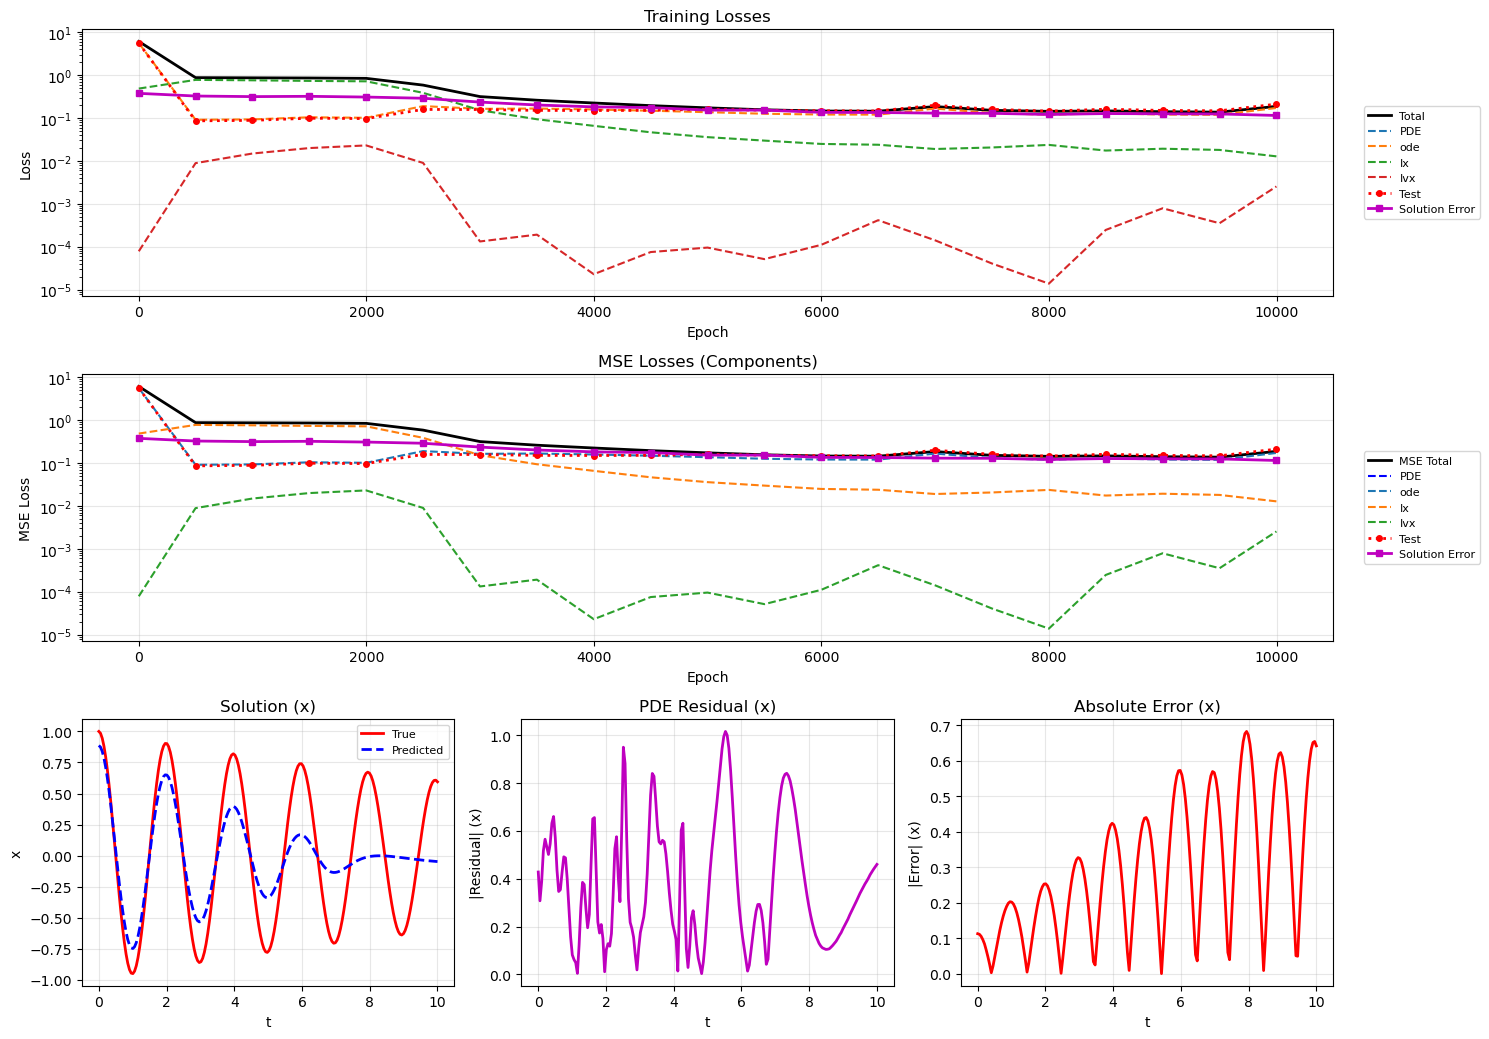

Epoch 0/10000 | Loss: 6.11e+00 | MSE Loss: 6.11e+00 | PDE: 0.00e+00 | BCs: [ode: 5.62e+00, Ix: 4.86e-01, Ivx: 7.81e-05] | Time: 0.0s | Test Loss: 5.60e+00 | Error: 3.76e-01
Epoch 500/10000 | Loss: 8.75e-01 | MSE Loss: 8.75e-01 | PDE: 0.00e+00 | BCs: [ode: 9.11e-02, Ix: 7.75e-01, Ivx: 8.88e-03] | Time: 5.1s | Test Loss: 8.59e-02 | Error: 3.26e-01
Epoch 1000/10000 | Loss: 8.66e-01 | MSE Loss: 8.66e-01 | PDE: 0.00e+00 | BCs: [ode: 9.29e-02, Ix: 7.58e-01, Ivx: 1.49e-02] | Time: 5.8s | Test Loss: 8.83e-02 | Error: 3.16e-01
Epoch 1500/10000 | Loss: 8.58e-01 | MSE Loss: 8.58e-01 | PDE: 0.00e+00 | BCs: [ode: 1.04e-01, Ix: 7.34e-01, Ivx: 1.99e-02] | Time: 6.5s | Test Loss: 9.89e-02 | Error: 3.21e-01
Epoch 2000/10000 | Loss: 8.42e-01 | MSE Loss: 8.42e-01 | PDE: 0.00e+00 | BCs: [ode: 1.01e-01, Ix: 7.17e-01, Ivx: 2.30e-02] | Time: 7.1s | Test Loss: 9.71e-02 | Error: 3.08e-01
Epoch 2500/10000 | Loss: 5.86e-01 | MSE Loss: 5.86e-01 | PDE: 0.00e+00 | BCs: [ode: 1.90e-01, Ix: 3.87e-01, Ivx: 8.98e-03] |

In [7]:
trainer = Trainer(problem, network)

trainer.compile(
    train_samples={"ode": 1000, "Ix": 1, "Ivx": 1},
    test_samples= {"ode": 1000},
    weights=      {"ode": 1.0,  "Ix": 1.0, "Ivx": 1.0},
    optimizer="adam",
    learning_rate=1e-3,
    epochs=10000,
    print_each=500,
    show_plots=True,
)

trainer.train()


# Solve with FB-PINN (Finite Basis PINN)

**FB-PINN** decomposes the domain into overlapping sub-domains, each covered by a small network with a smooth window function. This improves handling of oscillatory solutions and long time evolution.

We reuse the same `problem` and `domain` — only the model changes.

## Domain partition

We tile the time axis into 10 overlapping sub-domains using `PartitionFB`. The `overlap` parameter (0 – 1) controls the width of the transition region between adjacent sub-domains.


In [8]:
domain.set_partition(time=5)   # 10 equal time sub-domains

network_fb = create_model(
    domain,
    output_dim=1,
    hidden_dims=(32, 32),
    activation="tanh",
    partition=PartitionFB(overlap=0.5),
    denormalize=True,
    output_range=(-x0, x0),
)
print(network_fb)


ModelPartitioned(shape=5, strategy=PartitionFB, n_models=5, output_dim=1)
  ├─ sub_0: PartitionFB(overlap=0.5, continuity_weight=1.0, xmin=[0.0], xmax=[2.0])
  ├─ sub_1: PartitionFB(overlap=0.5, continuity_weight=1.0, xmin=[2.0], xmax=[4.0])
  ├─ sub_2: PartitionFB(overlap=0.5, continuity_weight=1.0, xmin=[4.0], xmax=[6.0])
  ├─ sub_3: PartitionFB(overlap=0.5, continuity_weight=1.0, xmin=[6.0], xmax=[8.0])
  └─ sub_4: PartitionFB(overlap=0.5, continuity_weight=1.0, xmin=[8.0], xmax=[10.0])


## Training

Same `problem` as before — the partition is embedded in `network_fb`.


Starting training for 10000 epochs (JIT-compiled)...


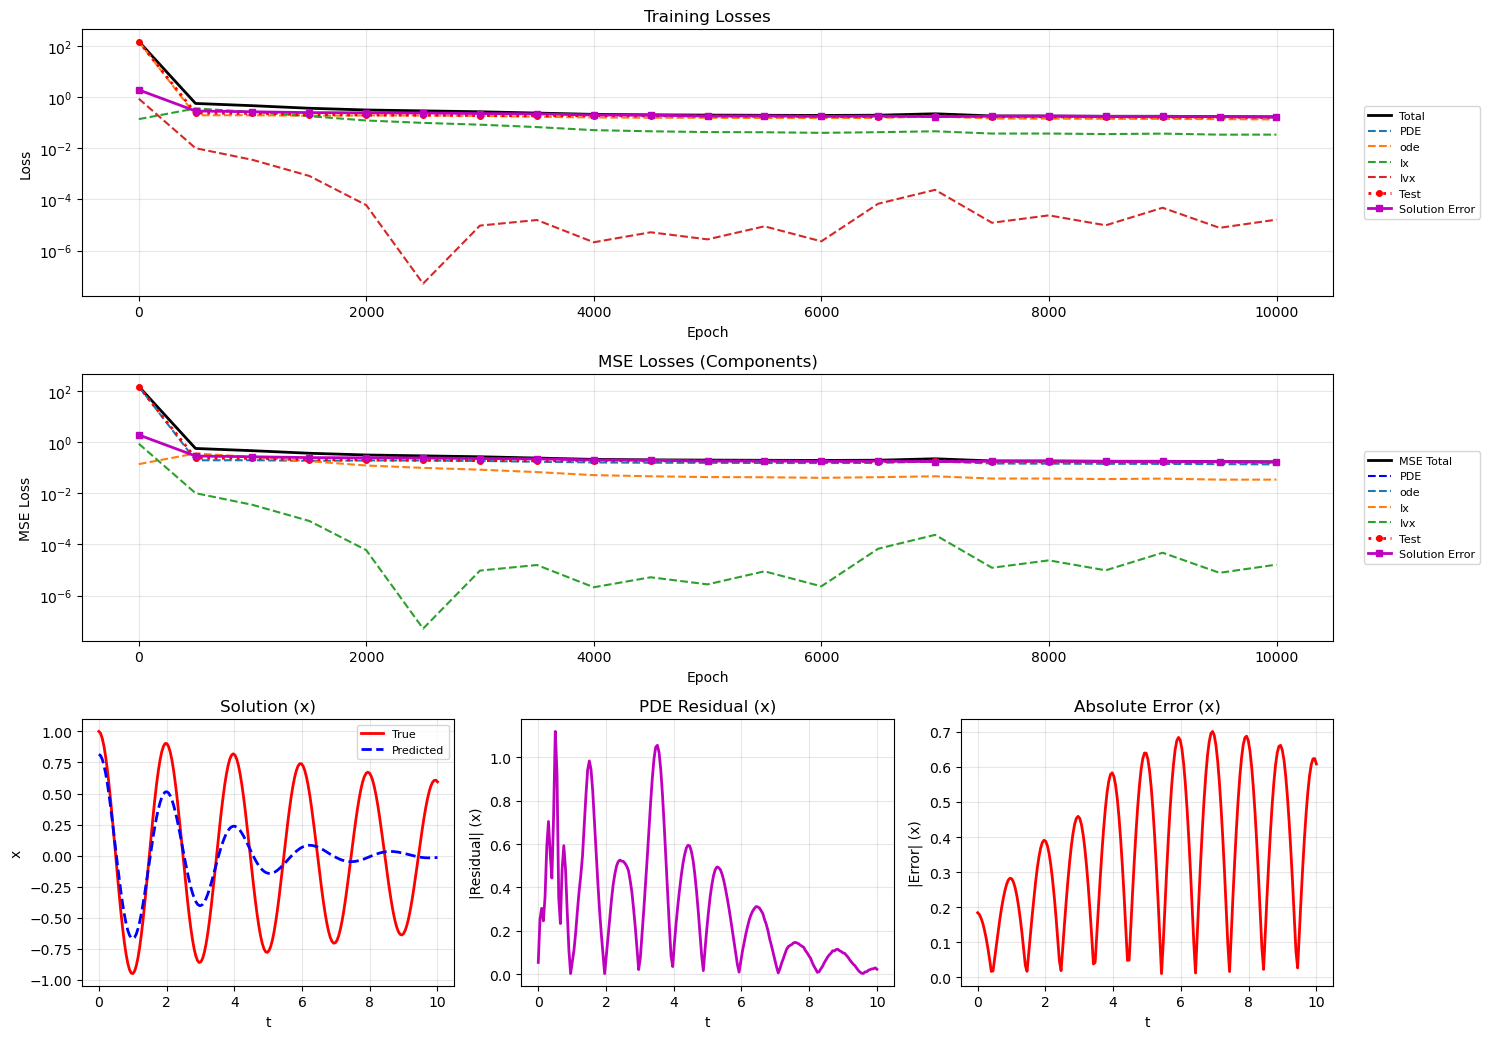

Epoch 0/10000 | Loss: 1.48e+02 | MSE Loss: 1.48e+02 | PDE: 0.00e+00 | BCs: [ode: 1.47e+02, Ix: 1.37e-01, Ivx: 8.54e-01] | Time: 0.0s | Test Loss: 1.46e+02 | Error: 1.89e+00
Epoch 500/10000 | Loss: 5.59e-01 | MSE Loss: 5.59e-01 | PDE: 0.00e+00 | BCs: [ode: 1.93e-01, Ix: 3.56e-01, Ivx: 1.00e-02] | Time: 6.9s | Test Loss: 2.36e-01 | Error: 2.84e-01
Epoch 1000/10000 | Loss: 4.57e-01 | MSE Loss: 4.57e-01 | PDE: 0.00e+00 | BCs: [ode: 1.94e-01, Ix: 2.60e-01, Ivx: 3.52e-03] | Time: 7.6s | Test Loss: 2.28e-01 | Error: 2.65e-01
Epoch 1500/10000 | Loss: 3.63e-01 | MSE Loss: 3.63e-01 | PDE: 0.00e+00 | BCs: [ode: 1.84e-01, Ix: 1.78e-01, Ivx: 8.25e-04] | Time: 8.3s | Test Loss: 2.05e-01 | Error: 2.46e-01
Epoch 2000/10000 | Loss: 3.11e-01 | MSE Loss: 3.11e-01 | PDE: 0.00e+00 | BCs: [ode: 1.90e-01, Ix: 1.21e-01, Ivx: 6.01e-05] | Time: 9.0s | Test Loss: 1.96e-01 | Error: 2.41e-01
Epoch 2500/10000 | Loss: 2.87e-01 | MSE Loss: 2.87e-01 | PDE: 0.00e+00 | BCs: [ode: 1.89e-01, Ix: 9.76e-02, Ivx: 5.17e-08] |

In [9]:
trainer_fb = Trainer(problem, network_fb)

trainer_fb.compile(
    train_samples={"ode": 1000, "Ix": 1, "Ivx": 1},
    test_samples= {"ode": 1000},
    weights=      {"ode": 1.0,  "Ix": 1.0, "Ivx": 1.0},
    optimizer="adam",
    learning_rate=1e-3,
    epochs=10000,
    print_each=500,
    show_plots=True
)

trainer_fb.train()

# Solve with Random Fourier Features PINN

## Model

We build the model with `create_model`: a normalised FNN with `tanh` activations, outputting in the physical range $[-x_0, x_0]$.


In [10]:
network = create_model(
    domain,
    output_dim=1,
    hidden_dims=(128, 128, 128),
    features=pinns.RandomFourierFeatures(128, encode_time=True),
    activation="tanh",
    denormalize=True,
    output_range=(-x0, x0),
)
print(network)


ModelBase(output_dim=1)
  [Normalize_0] Normalize(n_coord=1, n_context=0, context_scaled=False)
  [RandomFourierFeatures_1] RandomFourierFeatures(input_dim=1, n_features=128, sigma=1.0, encode_time=True)
  [FNN_2] FNN(layer_sizes=[256, 128, 128, 128, 1])
  [Denormalize_3] Denormalize(scaled=True)


## Training


Starting training for 10000 epochs (JIT-compiled)...


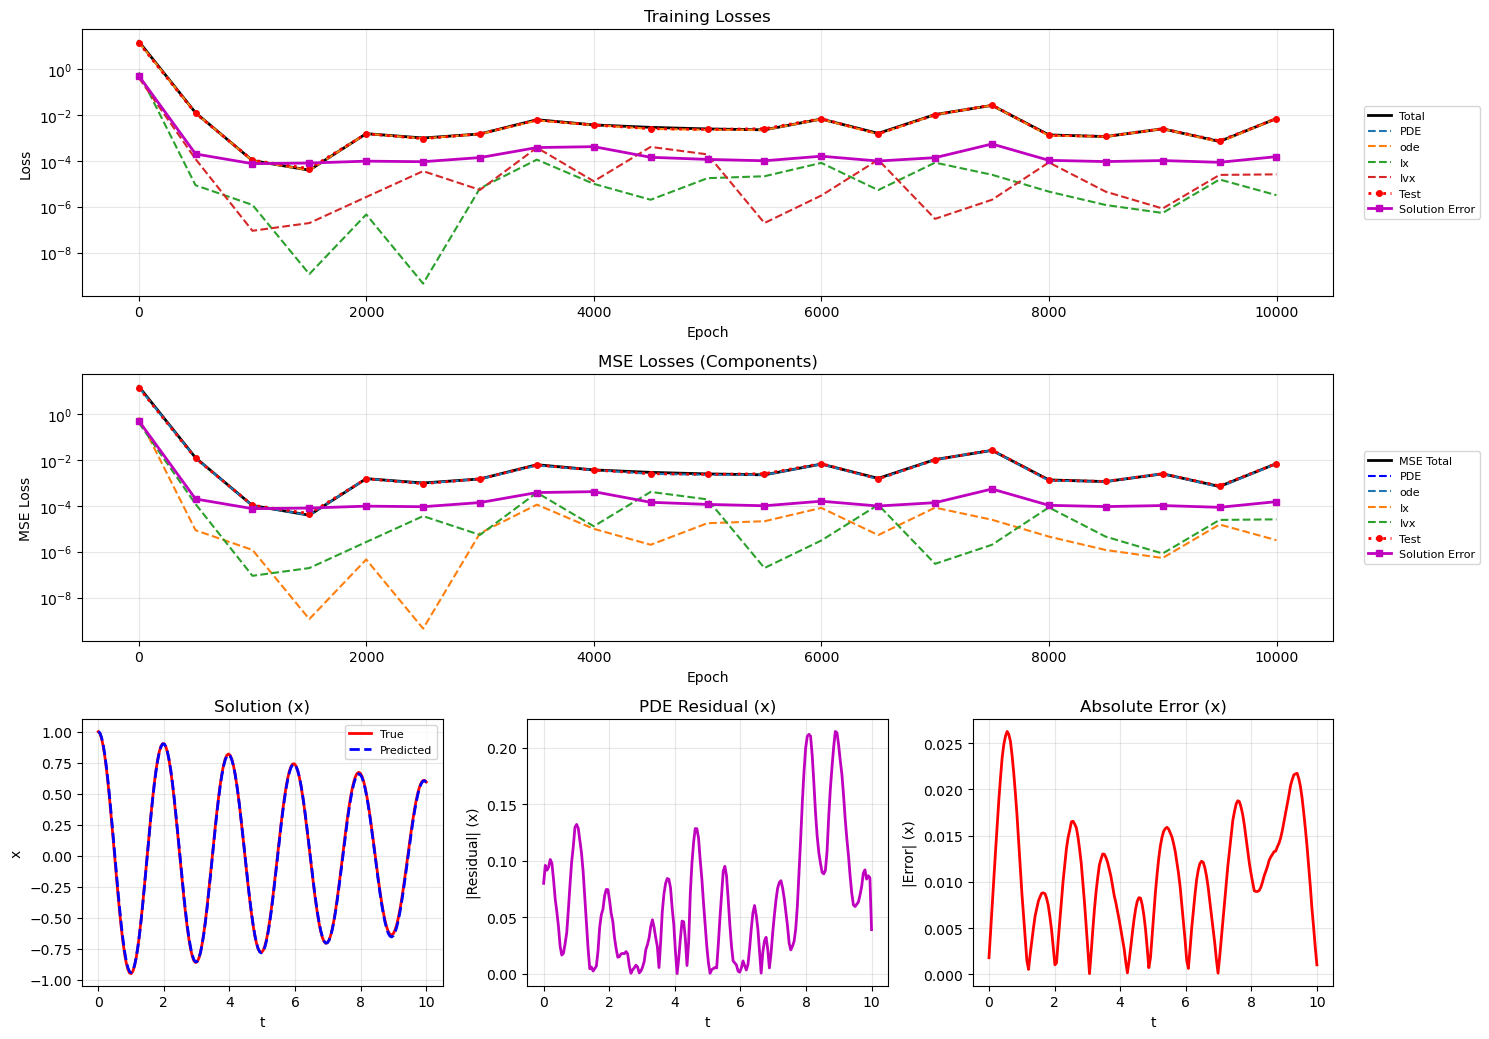

Epoch 0/10000 | Loss: 1.62e+01 | MSE Loss: 1.62e+01 | PDE: 0.00e+00 | BCs: [ode: 1.50e+01, Ix: 7.18e-01, Ivx: 4.23e-01] | Time: 0.0s | Test Loss: 1.41e+01 | Error: 5.13e-01
Epoch 500/10000 | Loss: 1.25e-02 | MSE Loss: 1.25e-02 | PDE: 0.00e+00 | BCs: [ode: 1.24e-02, Ix: 8.59e-06, Ivx: 1.20e-04] | Time: 3.3s | Test Loss: 1.18e-02 | Error: 1.99e-04
Epoch 1000/10000 | Loss: 1.03e-04 | MSE Loss: 1.03e-04 | PDE: 0.00e+00 | BCs: [ode: 1.02e-04, Ix: 1.20e-06, Ivx: 8.87e-08] | Time: 4.1s | Test Loss: 1.07e-04 | Error: 7.53e-05
Epoch 1500/10000 | Loss: 3.91e-05 | MSE Loss: 3.91e-05 | PDE: 0.00e+00 | BCs: [ode: 3.89e-05, Ix: 1.15e-09, Ivx: 1.93e-07] | Time: 4.8s | Test Loss: 4.60e-05 | Error: 8.01e-05
Epoch 2000/10000 | Loss: 1.54e-03 | MSE Loss: 1.54e-03 | PDE: 0.00e+00 | BCs: [ode: 1.53e-03, Ix: 4.58e-07, Ivx: 2.64e-06] | Time: 5.3s | Test Loss: 1.51e-03 | Error: 9.70e-05
Epoch 2500/10000 | Loss: 9.92e-04 | MSE Loss: 9.92e-04 | PDE: 0.00e+00 | BCs: [ode: 9.56e-04, Ix: 4.40e-10, Ivx: 3.56e-05] |

In [11]:
trainer = Trainer(problem, network)

trainer.compile(
    train_samples={"ode": 1000, "Ix": 1, "Ivx": 1},
    test_samples= {"ode": 1000},
    weights=      {"ode": 1.0,  "Ix": 1.0, "Ivx": 1.0},
    optimizer="adam",
    learning_rate=1e-3,
    epochs=10000,
    print_each=500,
    show_plots=True,
)

trainer.train()


# Solve with PirateNet PINN

## Model

We build the model with `create_model`: a normalised FNN with `tanh` activations, outputting in the physical range $[-x_0, x_0]$.


In [12]:
network = create_model(
    domain,
    output_dim=1,
    core=pinns.PirateNet(hidden_dim=128, n_blocks=3),
    activation="tanh",
    denormalize=True,
    output_range=(-x0, x0),
)
print(network)


ModelBase(output_dim=1)
  [Normalize_0] Normalize(n_coord=1, n_context=0, context_scaled=False)
  [PirateNet_1] PirateNet(input_dim=1, hidden_dim=128, n_blocks=3, output_dim=1)
  [Denormalize_2] Denormalize(scaled=True)


## Training


Starting training for 10000 epochs (JIT-compiled)...


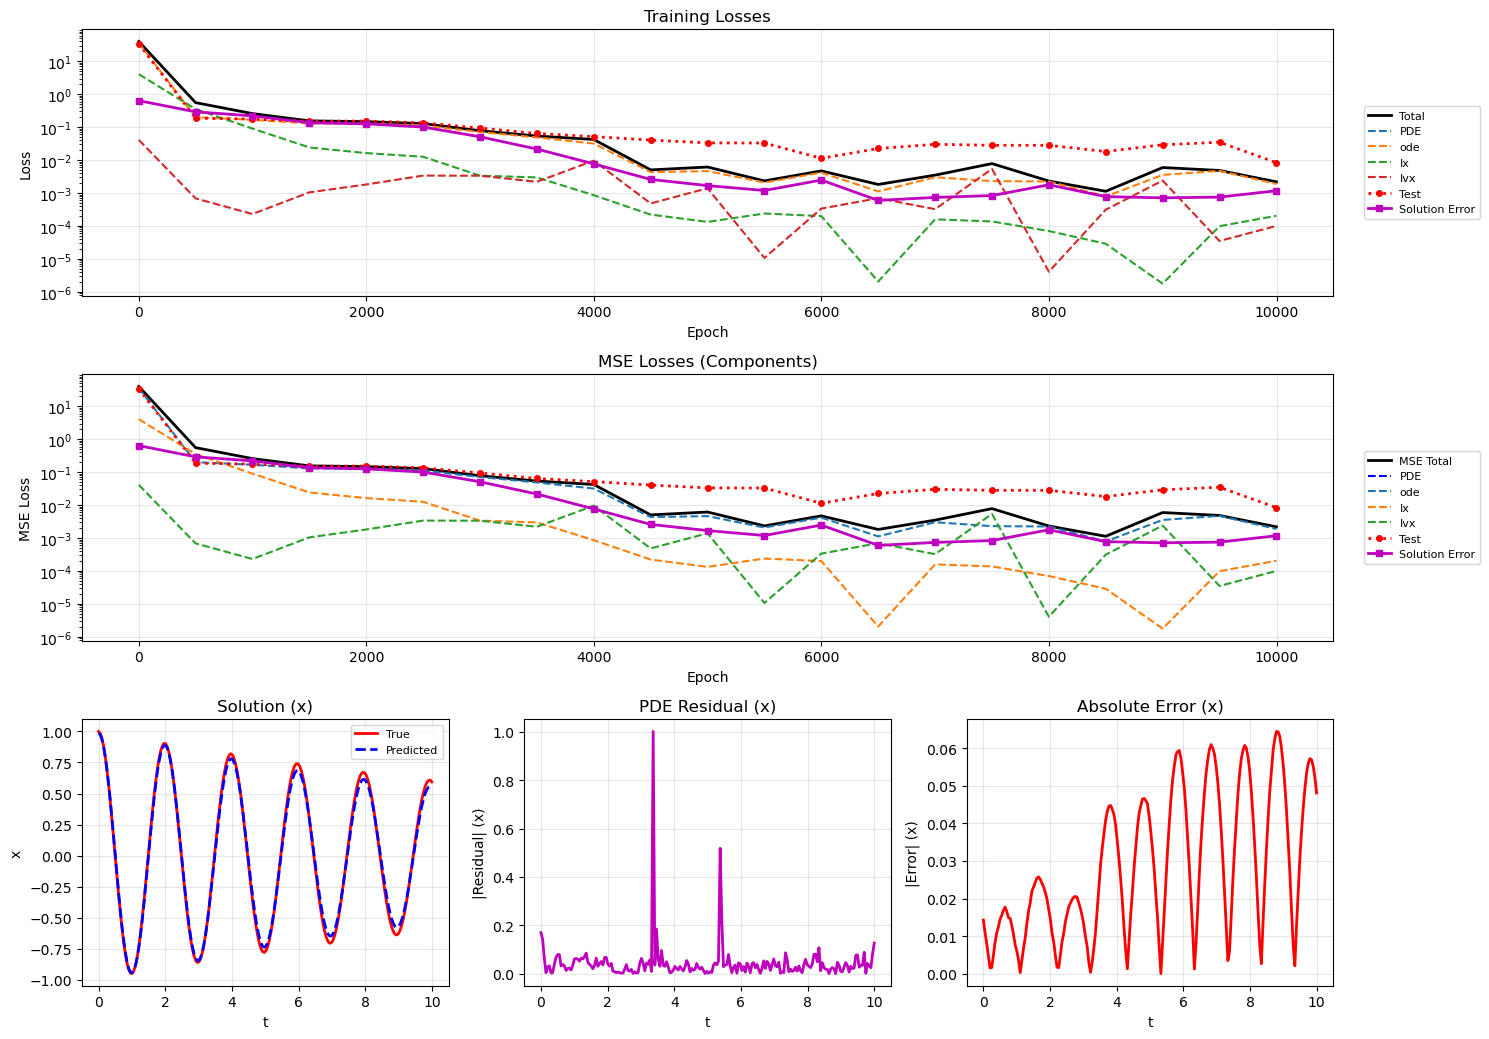

Epoch 0/10000 | Loss: 4.00e+01 | MSE Loss: 4.00e+01 | PDE: 0.00e+00 | BCs: [ode: 3.59e+01, Ix: 4.05e+00, Ivx: 4.11e-02] | Time: 0.0s | Test Loss: 3.40e+01 | Error: 6.39e-01
Epoch 500/10000 | Loss: 5.56e-01 | MSE Loss: 5.56e-01 | PDE: 0.00e+00 | BCs: [ode: 2.01e-01, Ix: 3.54e-01, Ivx: 6.88e-04] | Time: 10.0s | Test Loss: 1.87e-01 | Error: 2.91e-01
Epoch 1000/10000 | Loss: 2.58e-01 | MSE Loss: 2.58e-01 | PDE: 0.00e+00 | BCs: [ode: 1.67e-01, Ix: 9.04e-02, Ivx: 2.30e-04] | Time: 11.4s | Test Loss: 1.76e-01 | Error: 2.20e-01
Epoch 1500/10000 | Loss: 1.55e-01 | MSE Loss: 1.55e-01 | PDE: 0.00e+00 | BCs: [ode: 1.30e-01, Ix: 2.42e-02, Ivx: 1.05e-03] | Time: 12.9s | Test Loss: 1.51e-01 | Error: 1.37e-01
Epoch 2000/10000 | Loss: 1.47e-01 | MSE Loss: 1.47e-01 | PDE: 0.00e+00 | BCs: [ode: 1.29e-01, Ix: 1.63e-02, Ivx: 1.82e-03] | Time: 14.4s | Test Loss: 1.53e-01 | Error: 1.26e-01
Epoch 2500/10000 | Loss: 1.28e-01 | MSE Loss: 1.28e-01 | PDE: 0.00e+00 | BCs: [ode: 1.12e-01, Ix: 1.26e-02, Ivx: 3.38e-0

In [13]:
trainer = Trainer(problem, network)

trainer.compile(
    train_samples={"ode": 1000, "Ix": 1, "Ivx": 1},
    test_samples= {"ode": 1000},
    weights=      {"ode": 1.0,  "Ix": 1.0, "Ivx": 1.0},
    optimizer="adam",
    learning_rate=1e-3,
    epochs=10000,
    print_each=500,
    show_plots=True,
)

trainer.train()


# Solve with AL-PINN (Augmented Lagrangian)

**Augmented Lagrangian PINNs** enforce boundary/initial conditions as hard constraints via adaptive Lagrange multipliers rather than fixed penalty weights. This often improves convergence for stiff problems.

The same `domain` and `problem` are reused — only the Trainer compile call changes: set `auto_lagrangian=True` and pass `lagrange_constraints` to activate AL mode.


In [14]:
domain_al = DomainCubic(time=(0, t_max))  # fresh domain without FB partition

problem_al = ProblemStrong(
    domain=domain_al,
    output_names=["x"],
)

problem_al.add_inner(model_overdamped, name="ode", lagrange=False)

# Initial condition: x(0) = x0
problem_al.add_initial(1, outputs="x", name="Ix", lagrange=True)

problem_al.add_initial(initial_velocity, outputs="x", name="Ivx", lagrange=True)

# Fixed physical parameters
problem_al.add_fixed("omega", omega)
problem_al.add_fixed("beta",  beta)
problem_al.add_fixed("x0",    x0)

problem_al.add_solution(model_underdamped_analytic)

print(problem_al)
problem_al.show_problem()


ProblemStrong(domain=DomainCubic, n_dims=1, n_outputs=1, inner=1, boundary=0, initial=2, fixed=['omega', 'beta', 'x0'], inferred=[])


<IPython.core.display.Math object>

'\\min_\\theta\\,\\max_{\\boldsymbol{\\lambda}_{Ix},\\boldsymbol{\\lambda}_{Ivx}}\\;\\mathcal{L}(\\theta,\\boldsymbol{\\lambda})=\\frac{w_{ode}}{N_{ode}}\\left\\|\\mathcal{R}_{ode}\\right\\|_2^2 + \\frac{w_{Ix}}{N_{Ix}}\\left\\|\\mathcal{R}_{Ix}\\right\\|_2^2 + \\frac{1}{N_{Ix}}\\langle\\boldsymbol{\\lambda}_{Ix},\\,\\mathcal{R}_{Ix}\\rangle + \\frac{w_{Ivx}}{N_{Ivx}}\\left\\|\\mathcal{R}_{Ivx}\\right\\|_2^2 + \\frac{1}{N_{Ivx}}\\langle\\boldsymbol{\\lambda}_{Ivx},\\,\\mathcal{R}_{Ivx}\\rangle \\\\[4pt]\\begin{array}{l} \\mathcal{R}_{ode}:\\text{ PDE residual — ode (region: all)} \\\\ N_{ode}:\\text{ \\# samples for ode} \\\\ w_{ode}:\\text{ weight for ode} \\\\ \\mathcal{R}_{Ix}:\\text{ IC residual — Ix (region: initial)} \\\\ N_{Ix}:\\text{ \\# samples for Ix} \\\\ w_{Ix}:\\text{ weight for Ix} \\\\ \\boldsymbol{\\lambda}_{Ix}:\\text{ Lagrange multipliers for Ix} \\\\ \\mathcal{R}_{Ivx}:\\text{ IC residual — Ivx (region: initial)} \\\\ N_{Ivx}:\\text{ \\# samples for Ivx} \\\\ w_{Ivx

Starting training for 10000 epochs (JIT-compiled)...


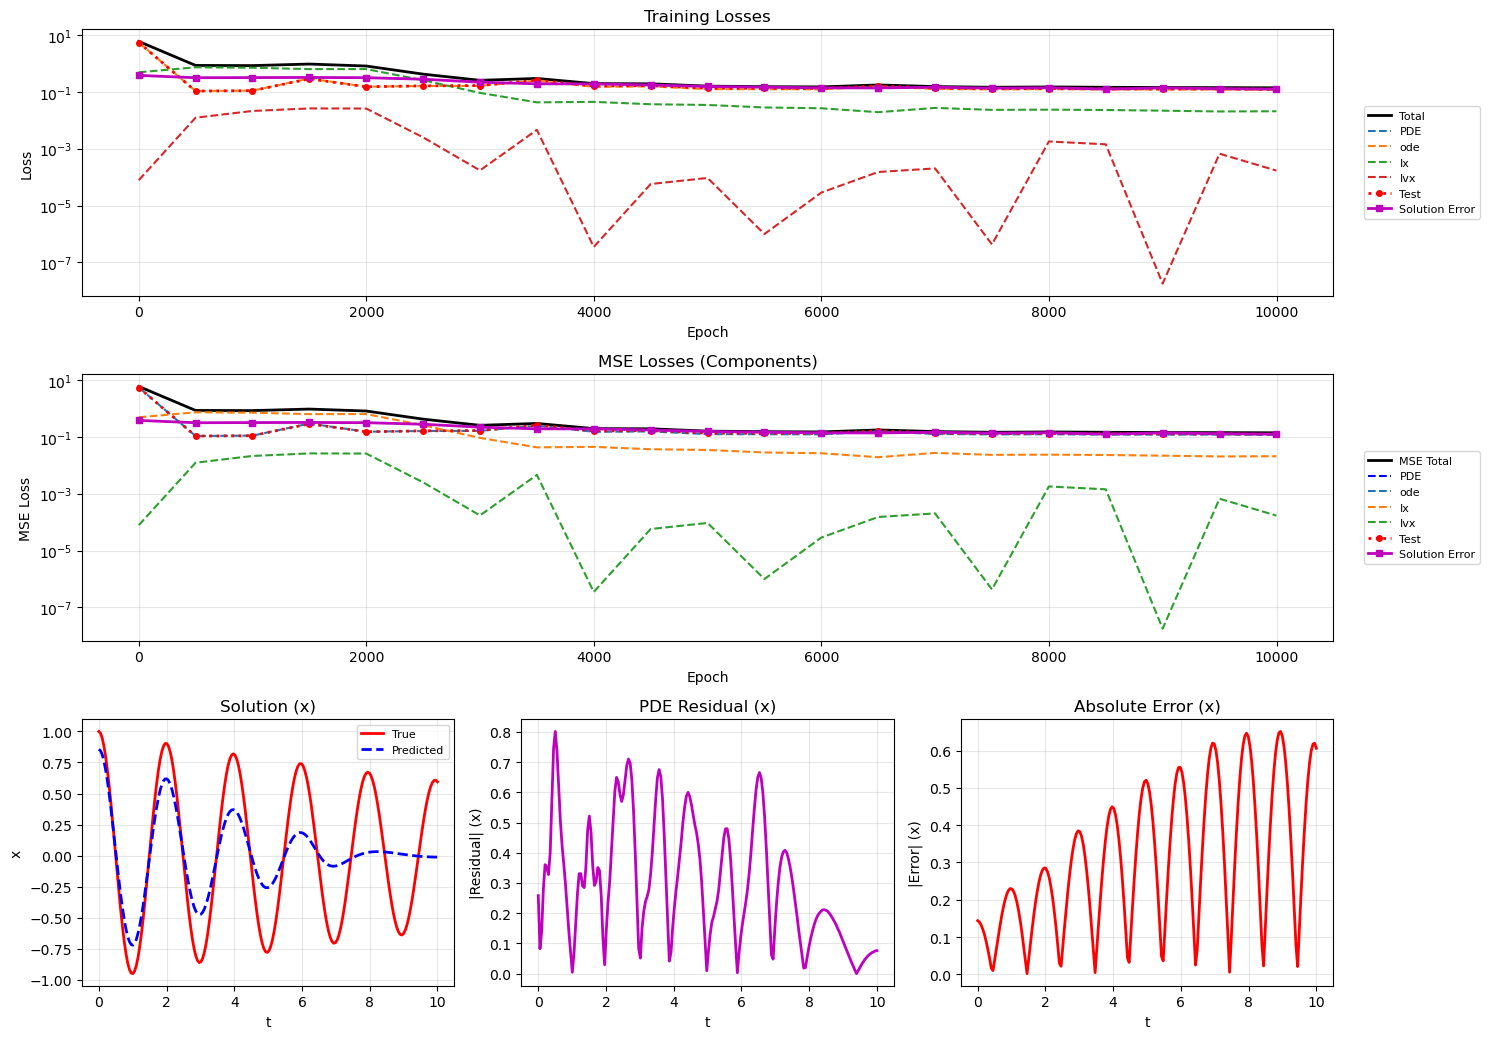

Epoch 0/10000 | Loss: 5.91e+00 | MSE Loss: 5.91e+00 | PDE: 0.00e+00 | BCs: [ode: 5.42e+00, Ix: 4.86e-01, Ivx: 7.81e-05] | Time: 0.0s | Test Loss: 5.42e+00 | Error: 3.78e-01
Epoch 500/10000 | Loss: 8.47e-01 | MSE Loss: 8.47e-01 | PDE: 0.00e+00 | BCs: [ode: 1.07e-01, Ix: 7.28e-01, Ivx: 1.23e-02] | Time: 1.4s | Test Loss: 1.06e-01 | Error: 3.13e-01
Epoch 1000/10000 | Loss: 8.35e-01 | MSE Loss: 8.35e-01 | PDE: 0.00e+00 | BCs: [ode: 1.10e-01, Ix: 7.04e-01, Ivx: 2.12e-02] | Time: 2.0s | Test Loss: 1.10e-01 | Error: 3.17e-01
Epoch 1500/10000 | Loss: 9.46e-01 | MSE Loss: 9.46e-01 | PDE: 0.00e+00 | BCs: [ode: 2.93e-01, Ix: 6.28e-01, Ivx: 2.61e-02] | Time: 2.6s | Test Loss: 2.86e-01 | Error: 3.20e-01
Epoch 2000/10000 | Loss: 8.07e-01 | MSE Loss: 8.07e-01 | PDE: 0.00e+00 | BCs: [ode: 1.51e-01, Ix: 6.30e-01, Ivx: 2.58e-02] | Time: 3.2s | Test Loss: 1.50e-01 | Error: 3.14e-01
Epoch 2500/10000 | Loss: 4.18e-01 | MSE Loss: 4.18e-01 | PDE: 0.00e+00 | BCs: [ode: 1.60e-01, Ix: 2.56e-01, Ivx: 2.50e-03] |

In [15]:
network_al = create_model(
    domain_al,
    output_dim=1,
    hidden_dims=(128, 128, 128),
    activation="tanh",
    denormalize=True,
    output_range=(-x0, x0),
)

trainer_al = Trainer(problem_al, network_al)

trainer_al.compile(
    train_samples={"ode": 1000, "Ix": 1, "Ivx": 1},
    test_samples= {"ode": 1000},
    weights=      {"ode": 1.0,  "Ix": 1.0, "Ivx": 1.0},
    optimizer="adam",
    learning_rate=1e-3,
    epochs=10000,
    print_each=500,
    show_plots=True,
    lagrange_lr=1e-3,
)

trainer_al.train()
